In [2]:
# ================== INSTALL ==================
!pip install transformers torch torchvision scikit-learn wandb

In [4]:

# ================== IMPORTS ==================
import os, zipfile, warnings
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from torchvision import transforms
from transformers import ViTForImageClassification

from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import wandb
warnings.filterwarnings("ignore")

# ================== DRIVE ==================
from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_PATH = "/content/drive/MyDrive/vit_checkpoint.pth"
BEST_MODEL_PATH = "/content/drive/MyDrive/vit_best.pth"

# ================== SEED ==================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# ================== UNZIP ==================
zip_path     = "/content/archive.zip"
extract_path = "/content/archive_Extracted"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)

data_dir = os.path.join(extract_path, "OriginalDataset")

# ================== CLASSES / DEVICE ==================
classes      = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
num_classes  = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Classes: {classes}")
print(f"Device : {device}")

# ================== LOAD PATHS ==================
all_samples = []
for cls in classes:
    cls_dir = os.path.join(data_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            all_samples.append((os.path.join(cls_dir, fname), class_to_idx[cls]))

# ================== PATIENT SPLIT ==================
def get_patient_id(path):
    fname = os.path.basename(path)
    return fname.split(" ")[0] if "(" in fname else fname.split('.')[0]

patient_map = defaultdict(list)
for path, label in all_samples:
    patient_map[get_patient_id(path)].append((path, label))

patients = list(patient_map.keys())
train_p, temp_p = train_test_split(patients, test_size=0.3, random_state=42)
val_p,   test_p = train_test_split(temp_p,   test_size=0.5, random_state=42)
assert len(set(train_p) & set(test_p)) == 0

train_samples = [s for p in train_p for s in patient_map[p]]
val_samples   = [s for p in val_p   for s in patient_map[p]]
test_samples  = [s for p in test_p  for s in patient_map[p]]
print(f"Train: {len(train_samples)}  Val: {len(val_samples)}  Test: {len(test_samples)}")

# ─────────────────────────────────────────────────────────────────────────────
# THE REAL FIX FOR COLAB: PRE-CACHE ALL IMAGES AS TENSORS IN RAM
# ─────────────────────────────────────────────────────────────────────────────
# Colab has 2 vCPUs and slow tmpfs disk. Every __getitem__ that opens a file
# pays ~40-100ms in disk seek + PIL decode + normalize. With 4480 images × 20
# epochs that is millions of redundant disk reads.
#
# Strategy: read every image ONCE at startup, apply the deterministic steps
# (resize, crop, normalize) and store the result as a float16 tensor in RAM.
# __getitem__ becomes a dict lookup (~0ms) + a fast tensor augmentation.
# num_workers=0 is then completely fine — there is nothing slow to parallelise.
#
# RAM cost: 4480 images × 3 × 224 × 224 × 2 bytes (float16) ≈ 1.3 GB — well
# within Colab's 12 GB limit.
# ─────────────────────────────────────────────────────────────────────────────
base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),                          # → float32 [0,1]
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

print("\nPre-caching images into RAM (runs once)...")
image_cache = {}
unique_paths = list({path for path, _ in all_samples})
for path in tqdm(unique_paths):
    img = Image.open(path).convert("RGB")
    # Store as float16 to halve RAM usage (~1.3 GB vs 2.6 GB)
    image_cache[path] = base_transform(img).half()

print(f"Cache size: {len(image_cache)} tensors")

# ─────────────────────────────────────────────────────────────────────────────
# AUGMENTATION APPLIED TO TENSORS (no PIL needed at training time)
# ─────────────────────────────────────────────────────────────────────────────
# These torchvision ops accept tensors directly, making them extremely fast.
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), antialias=True),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

# ================== DATASET ==================
class AlzheimerDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # Cache lookup — ~0ms
        tensor = image_cache[path].float()          # float16 → float32 for ops
        if self.augment:
            tensor = train_aug(tensor)
        return tensor, label

# ─────────────────────────────────────────────────────────────────────────────
# num_workers=0: correct for Colab when __getitem__ is pure RAM.
# Spawning workers has overhead; here there is nothing to parallelise.
# pin_memory=True still helps even with num_workers=0 for the collate step.
# ─────────────────────────────────────────────────────────────────────────────
BATCH_SIZE = 32     # safe for ViT-base on T4/V100; try 64 if nvidia-smi shows <70% mem

train_loader = DataLoader(AlzheimerDataset(train_samples, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(AlzheimerDataset(val_samples),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(AlzheimerDataset(test_samples),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# ================== CLASS WEIGHTS ==================
train_labels = [y for _, y in train_samples]
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights = torch.tensor(weights, dtype=torch.float).to(device)

# ================== MODEL ==================
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
).to(device)

# ─────────────────────────────────────────────────────────────────────────────
# DIFFERENTIAL LEARNING RATES
# Classifier head is random → needs 1e-3 to learn quickly.
# Pretrained backbone → keep at 2e-5 to preserve representations.
# Using a single LR for both was causing near-zero train accuracy.
# ─────────────────────────────────────────────────────────────────────────────
backbone_params = [p for n, p in model.named_parameters() if "classifier" not in n]
head_params     = [p for n, p in model.named_parameters() if "classifier"     in n]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 2e-5,  "weight_decay": 0.01},
    {"params": head_params,     "lr": 1e-3,  "weight_decay": 0.01},
])

# ─────────────────────────────────────────────────────────────────────────────
# WARMUP + COSINE DECAY (step-level, not epoch-level)
# ─────────────────────────────────────────────────────────────────────────────
EPOCHS        = 20
WARMUP_EPOCHS = 2
steps_per_epoch = len(train_loader)
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(weight=weights)   # no label_smoothing with class weights
scaler    = GradScaler("cuda")

# ================== WANDB ==================
wandb.init(project="alzheimers-vit", name="colab_cached_pipeline")

# ================== RESUME ==================
start_epoch  = 0
best_val_acc = 0.0

if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint — attempting resume...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(ckpt['model'])      # model weights are always compatible

    try:
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_acc']
        print(f"✅ Full resume from epoch {start_epoch}, best val acc {best_val_acc:.4f}")

    except ValueError:
        # Old checkpoint used single param group — optimizer state is incompatible.
        # We keep the model weights but restart optimizer/scheduler from scratch.
        start_epoch  = 0
        best_val_acc = ckpt.get('best_acc', 0.0)
        print("⚠️  Optimizer param groups changed — resuming model weights only.")
        print(f"   best_val_acc carried over: {best_val_acc:.4f}")

# ================== TRAINING LOOP ==================
patience = 5
counter  = 0

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss = train_correct = train_total = 0

    for x, y in tqdm(train_loader, desc="train"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast("cuda"):
            logits = model(x).logits
            loss   = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        pred = logits.argmax(1)
        train_correct += (pred == y).sum().item()
        train_total   += y.size(0)
        train_loss    += loss.item()

    train_acc  = train_correct / train_total
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="val  "):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast("cuda"):
                logits = model(x).logits
                loss   = criterion(logits, y)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total   += y.size(0)
            val_loss    += loss.item()

    val_acc  = val_correct / val_total
    val_loss /= len(val_loader)

    lrs = [g['lr'] for g in optimizer.param_groups]
    print(f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | "
          f"LR backbone={lrs[0]:.2e} head={lrs[1]:.2e}")

    wandb.log({"train_acc": train_acc, "val_acc": val_acc,
               "train_loss": train_loss, "val_loss": val_loss,
               "lr_backbone": lrs[0], "lr_head": lrs[1], "epoch": epoch})

    torch.save({
        'epoch': epoch, 'model': model.state_dict(),
        'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(), 'best_acc': best_val_acc,
    }, CHECKPOINT_PATH)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved!")
    else:
        counter += 1
        print(f"Early stop counter {counter}/{patience}")
        if counter >= patience:
            print("🛑 Early stopping")
            break

    if val_acc > 0.98:
        print("🚨 Check for data leakage!")

# ================== TEST ==================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
preds, labels_list = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="test"):
        x = x.to(device, non_blocking=True)
        with autocast("cuda"):
            logits = model(x).logits
        preds.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(y.numpy())

print("Accuracy:         ", accuracy_score(labels_list, preds))
print("Balanced Accuracy:", balanced_accuracy_score(labels_list, preds))
print(classification_report(labels_list, preds, target_names=classes))
wandb.finish()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Device : cuda
Train: 4264  Val: 1167  Test: 969

Pre-caching images into RAM (runs once)...


100%|██████████| 6400/6400 [00:39<00:00, 160.87it/s]


Cache size: 6400 tensors


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


...

val  : 100%|██████████| 37/37 [00:03<00:00, 11.83it/s]


Train: 0.9852 | Val: 0.7584 | LR backbone=0.00e+00 head=0.00e+00
Early stop counter 2/5


test: 100%|██████████| 31/31 [00:02<00:00, 11.08it/s]

Accuracy:          0.7337461300309598
Balanced Accuracy: 0.7542981964956487
                  precision    recall  f1-score   support

    MildDemented       0.80      0.61      0.69       140
ModerateDemented       0.86      0.92      0.89        13
     NonDemented       0.78      0.81      0.79       471
VeryMildDemented       0.65      0.67      0.66       345

        accuracy                           0.73       969
       macro avg       0.77      0.75      0.76       969
    weighted avg       0.74      0.73      0.73       969



epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr_backbone,▅████▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁
lr_head,▅████▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁
train_acc,▁▃▃▄▅▅▆▆▇▇▇▇▇███████
train_loss,█▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▂▅▁▂▃▇▅▅▇▇▆▇▇▇▇▇▇███
val_loss,▄▁▃▄▄▁▂▄▄▅▆▆▆▇▆▇█▇▇▇
epoch,19
lr_backbone,0
lr_head,0
train_acc,0.98523


<Figure size 640x480 with 0 Axes>

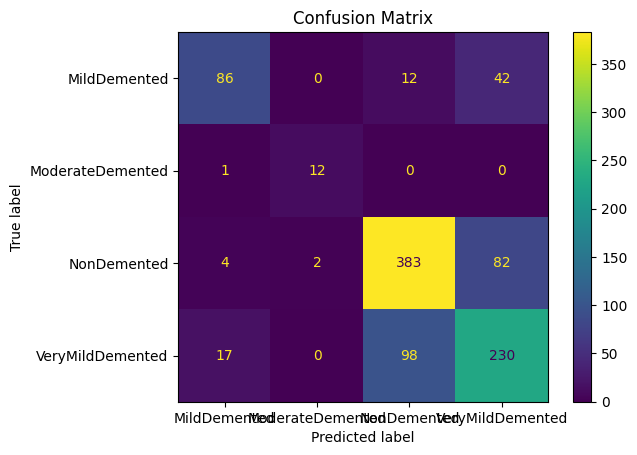

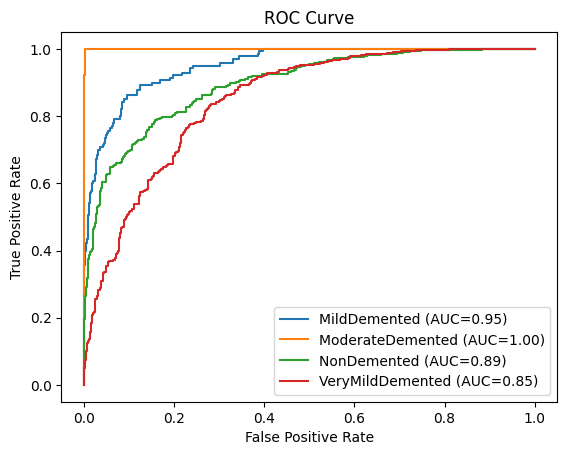

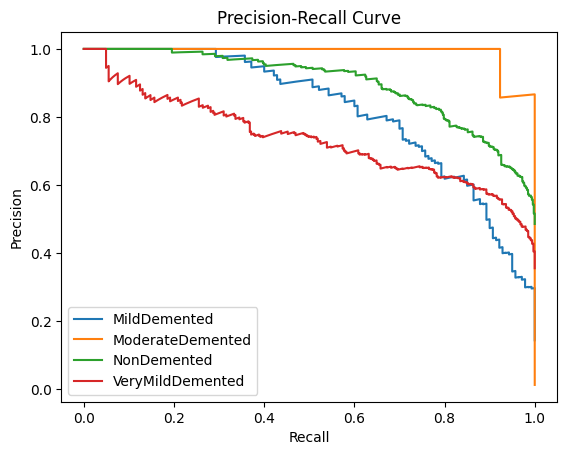

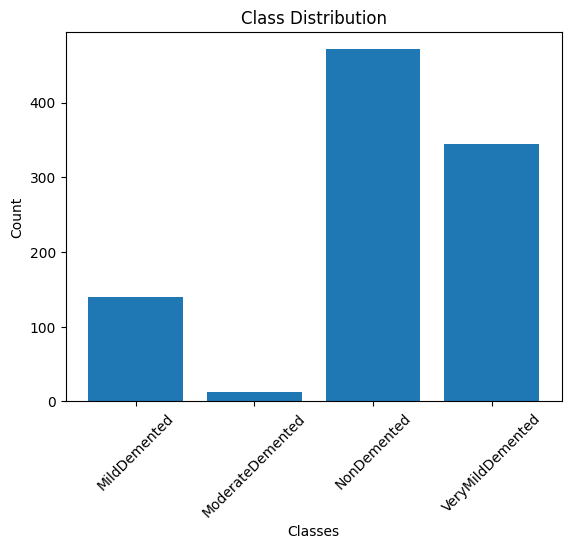

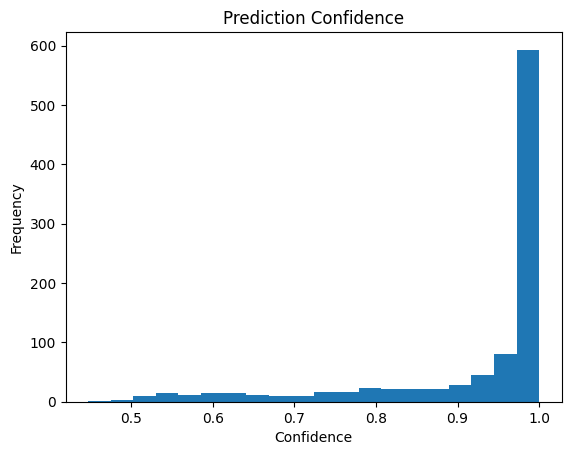

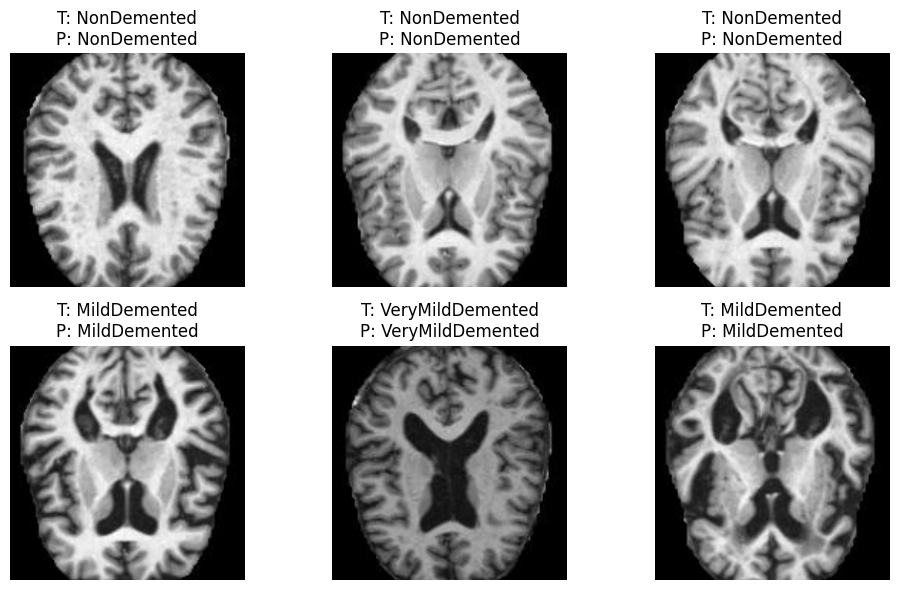

In [11]:
# ================== VISUALIZATION FOR EXISTING MODEL ==================
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

# ================== COLLECT PREDICTIONS AGAIN ==================
model.eval()

preds, labels_list, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        logits = model(x).logits
        probs = torch.softmax(logits, dim=1)

        preds.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true  = np.array(labels_list)
y_pred  = np.array(preds)
y_probs = np.array(all_probs)

num_classes = len(classes)

# ================== 1. CONFUSION MATRIX ==================
plt.figure()
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=None)
plt.title("Confusion Matrix")
plt.show()

# ================== 2. ROC CURVE ==================
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ================== 3. PRECISION-RECALL ==================
plt.figure()
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    plt.plot(recall, precision, label=f"{classes[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ================== 4. CLASS DISTRIBUTION ==================
counts = np.bincount(y_true)

plt.figure()
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

# ================== 5. CONFIDENCE HISTOGRAM ==================
confidences = np.max(y_probs, axis=1)

plt.figure()
plt.hist(confidences, bins=20)
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Prediction Confidence")
plt.show()

# ================== 6. SAMPLE PREDICTIONS ==================
dataset = AlzheimerDataset(test_samples, augment=False)

model.eval()
indices = random.sample(range(len(dataset)), min(6, len(dataset)))

plt.figure(figsize=(10, 6))

for i, idx in enumerate(indices):
    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor).logits
        pred = logits.argmax(1).item()

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5)

    plt.subplot(2, 3, i+1)
    plt.imshow(img_np)
    plt.title(f"T: {classes[label]}\nP: {classes[pred]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
!pip install fastapi uvicorn pyngrok python-multipart nest_asyncio




In [22]:
from transformers import ViTForImageClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True   # 🔥 IMPORTANT FIX
)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.to(device)
model.eval()


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [23]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # use same as training
])


In [24]:
from fastapi import FastAPI, UploadFile, File
import io

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Alzheimer's Model API is running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image = Image.open(io.BytesIO(await file.read())).convert("RGB")
    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img).logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return {
        "predicted_class": classes[pred],
        "confidence": float(probs[0][pred])
    }


In [25]:
!ngrok config add-authtoken 3CL5IcYyNs8ohl2CXFgixW48N4o_4etEusoNfNU87yBKqx623


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [26]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)
print("🚀 API LIVE AT:", public_url)


🚀 API LIVE AT: NgrokTunnel: "https://frighten-uneaten-outboard.ngrok-free.dev" -> "http://localhost:8000"


In [30]:
!pip install nest_asyncio


In [28]:
import nest_asyncio
nest_asyncio.apply()


In [32]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server)
thread.start()



In [50]:
!pip install gradio

import gradio as gr
import torch
import numpy as np
from PIL import Image
import pandas as pd
import time

# ================== MRI VALIDATION ==================
def is_valid_mri(image):
    img = np.array(image)

    # Convert to grayscale check
    if len(img.shape) == 3:
        r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

        diff_rg = np.mean(np.abs(r - g))
        diff_rb = np.mean(np.abs(r - b))

        # Reject colorful images
        if diff_rg > 10 or diff_rb > 10:
            return False

    # Reject very low contrast images
    if np.std(img) < 15:
        return False

    return True


# ================== PREDICTION ==================
def predict(image):
    image = image.convert("RGB")
    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        start = time.time()
        logits = model(img).logits
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        end = time.time()

    pred_idx = np.argmax(probs)
    pred_label = classes[pred_idx]
    confidence = probs[pred_idx]

    # DataFrame (no prediction column)
    df = pd.DataFrame({
        "Stage": classes,
        "Prediction (%)": [round(p * 100, 2) for p in probs]
    })

    # Highlight predicted row
    def highlight_row(row):
        if row.name == pred_idx:
            return ['background-color: #dcfce7; color: #166534; font-weight: 600'] * len(row)
        else:
            return [''] * len(row)

    df = df.style.apply(highlight_row, axis=1)

    inference_time = round(end - start, 3)

    return pred_label, confidence, df, inference_time


# ================== REPORT ==================
def generate_report(pred, conf):
    conf_percent = conf * 100

    if "Non" in pred:
        risk = "Low Risk"
        note = "No significant cognitive impairment detected."
    elif "Very Mild" in pred:
        risk = "Early Stage"
        note = "Minor signs observed. Monitoring recommended."
    elif "Mild" in pred:
        risk = "Moderate Risk"
        note = "Noticeable cognitive decline. Clinical evaluation advised."
    else:
        risk = "High Risk"
        note = "Severe impairment detected. Immediate medical attention recommended."

    return f"""
### Diagnosis: {pred}

**Confidence:** {conf_percent:.2f}%

**Severity:** {risk}

**Clinical Note:**
{note}
"""


# ================== MAIN FUNCTION ==================
def run_all(image):
    if image is None:
        return "Please enter a valid Image for analysis", "", None

    # MRI validation check
    if not is_valid_mri(image):
        return "Please enter a valid Image for analysis", "", None

    pred, conf, df, t = predict(image)
    report = generate_report(pred, conf)

    status = f"Analysis completed in {t} seconds"

    return status, report, df


# ================== CSS ==================
css = """
body {
    background: #f8fafc;
    color: #1e293b;
}

.gradio-container {
    font-family: 'Inter', sans-serif;
}

/* HEADER */
#header {
    text-align: center;
    font-size: 32px;
    font-weight: 700;
    color: #0f172a;
    background: #e2e8f0;
    padding: 12px;
    border-radius: 12px;
    margin-bottom: 5px;
}

/* SUBHEADER */
#subheader {
    text-align: center;
    font-size: 14px;
    color: #64748b;
    margin-bottom: 20px;
}

/* CARD */
.card {
    background: #ffffff;
    border: 1px solid #e2e8f0;
    padding: 20px;
    border-radius: 12px;
    box-shadow: 0 4px 10px rgba(0,0,0,0.04);
}

/* BUTTON */
button {
    background: #e2e8f0 !important;
    color: #0f172a !important;
    border: 1px solid #cbd5e1 !important;
    border-radius: 8px !important;
    font-weight: 500;
}

button:hover {
    background: #cbd5e1 !important;
}

/* REPORT */
.report {
    font-size: 14px;
    color: #334155;
    line-height: 1.6;
}

/* TABLE */
table {
    background: white !important;
    color: #1e293b !important;
    border: 1px solid #e2e8f0;
}
"""


# ================== EDUCATION ==================
education = """
Alzheimer’s disease is a progressive neurological disorder affecting memory and cognition.

### Stages:

**Non-Demented**
No detectable cognitive decline.

**Very Mild Demented**
Minor forgetfulness and slight confusion.

**Mild Demented**
Noticeable memory issues and difficulty in tasks.

**Moderate Demented**
Severe decline requiring assistance in daily activities.
"""


# ================== UI ==================
with gr.Blocks(css=css) as demo:

    gr.Markdown("<div id='header'>BrainVision</div>")
    gr.Markdown("<div id='subheader'>- Best Alzheimer Stage Detection AI Tool</div>")

    with gr.Tabs():

        with gr.Tab("Education"):
            gr.HTML("""
    <iframe
        src="https://https://www.brightfocus.org/resource/how-does-alzheimers-disease-affect-the-brain/"
        width="100%"
        height="600px"
        style="border:none; border-radius:12px;">
    </iframe>
    """)

        with gr.Tab("Diagnosis"):
            with gr.Row():

                with gr.Column(scale=1):
                    with gr.Group(elem_classes="card"):
                        image_input = gr.Image(type="pil", label="Upload MRI Scan")
                        analyze_btn = gr.Button("Run Analysis")
                        status = gr.Markdown("")

                with gr.Column(scale=1):
                    with gr.Group(elem_classes="card"):
                        report_output = gr.Markdown(elem_classes="report")
                        prob_output = gr.Dataframe()

        with gr.Tab("Contact"):
            gr.Markdown("""
Project Initiative by Nishant Negi & Ashwani Sharma

Contact Numbers: 9720660443, 9548732695
Emails: S25MCAG0100@bennett.edu.in, S25MCAG0098@bennett.edu.in
Esteemed Mentor - Dr. Anuj Kumar Bharti [SCSET]

Bennett University
""")

    analyze_btn.click(
        fn=run_all,
        inputs=image_input,
        outputs=[status, report_output, prob_output]
    )

# ================== LAUNCH ==================
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://12e431020bf36fcfeb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
